In [3]:
%pip install -q contextily folium mapclassify

Note: you may need to restart the kernel to use updated packages.


In [1]:
%%capture
%env AWS_ACCESS_KEY_ID=
%env AWS_SECRET_ACCESS_KEY=
%env AWS_SESSION_TOKEN=
%env AWS_REQUEST_PAYER=requester

In [4]:
from os.path import join, basename
from glob import glob
import gc
from functools import partial

from rastervision.pipeline.file_system.utils import (
    file_exists, file_to_json, json_to_file, list_paths, uri_to_vsi_path)
from rastervision.core.box import Box, SlidingWindows
from rastervision.core.data import (
    geoms_to_geojson, RasterioSource, RasterioCRSTransformer, Scene)
from rastervision.core.data.utils import (geoms_to_geojson)
from rastervision.core.data.raster_source.stac_config import subset_assets
from rastervision.pytorch_learner.dataset import (
    SemanticSegmentationSlidingWindowGeoDataset)

from tqdm.auto import tqdm, trange
import albumentations as A
import numpy as np
import torch
from torch.utils.data import ConcatDataset, DataLoader
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
sns.reset_defaults()
import contextily as cx

import pystac_client
from pystac import ItemCollection
from shapely.geometry import mapping, shape, Point
import pandas as pd
import geopandas as gpd
import rasterio as rio

In [5]:
catalog = pystac_client.Client.open('https://earth-search.aws.element84.com/v1')

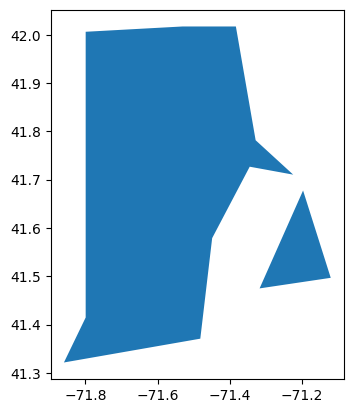

In [6]:
df = gpd.read_file('data/us-states.json')
df_aoi = df[df.name == 'Rhode Island']
df_aoi.plot()
plt.show()

In [7]:
aoi = df_aoi.geometry.unary_union.simplify(0)
aoi_name = 'RI'
year_old = 2018
year_new = 2021

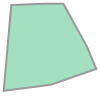

In [140]:
aoi.convex_hull

In [10]:
items_old = catalog.search(
    intersects=mapping(aoi),
    collections=['naip'],
    datetime=str(year_old),
    # datetime=f'{year_old}-01-01/{year_old + 1}-01-01',
).item_collection()
len(items_old)

140

In [9]:
items_new = catalog.search(
    intersects=mapping(aoi),
    collections=['naip'],
    datetime=f'{year_new}-01-01/{year_new + 1}-01-01',
).item_collection()
len(items_new)

141

In [11]:
items_path_new = f'data/stac_items_naip_{aoi_name}_{year_new}.json'
# json_to_file(items_new.to_dict(), items_path_new)
items_new = ItemCollection.from_file(items_path_new)

In [12]:
items_path_old = f'data/stac_items_naip_{aoi_name}_{year_old}.json'
# json_to_file(items_old.to_dict(), items_path_old)
items_old = ItemCollection.from_file(items_path_old)

In [20]:
df_items_old.within(aoi)

0      False
1      False
2      False
3      False
4      False
       ...  
133     True
134     True
135     True
136     True
137     True
Length: 104, dtype: bool

In [19]:
df_items_old.loc[:, 'test'] = df_items_old.within(aoi)

In [13]:
df_items_old = gpd.GeoDataFrame.from_features(items_old, crs=4326)
df_items_old.loc[:, 'id'] = [item.id for item in items_old]
df_items_old.loc[:, 'uri'] = [item.assets['image'].href for item in items_old]
df_items_new = gpd.GeoDataFrame.from_features(items_new, crs=4326)
df_items_new.loc[:, 'id'] = [item.id for item in items_new]
df_items_new.loc[:, 'uri'] = [item.assets['image'].href for item in items_new]
len(df_items_old), len(df_items_new)

(140, 141)

In [14]:
df_items_old = df_items_old[df_items_old.id.str.startswith(aoi_name.lower())].copy()
df_items_new = df_items_new[df_items_new.id.str.startswith(aoi_name.lower())].copy()
df_items_old = df_items_old.drop_duplicates(['uri'])
df_items_new = df_items_new.drop_duplicates(['uri'])
len(df_items_old), len(df_items_new)

(104, 104)

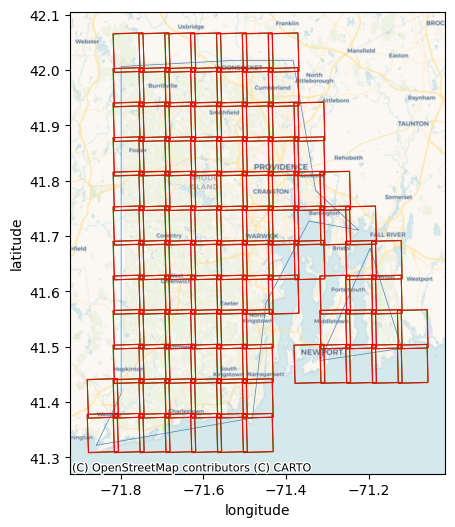

In [15]:
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6))
df_aoi.plot(ax=ax, ec='steelblue', fc='none', lw=0.5)
df_items_old.plot(ax=ax, ec='g', fc='none', lw=0.75)
df_items_new.plot(ax=ax, ec='r', fc='none', lw=0.75)
cx.add_basemap(ax, crs='epsg:4326', source=cx.providers.CartoDB.Voyager)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

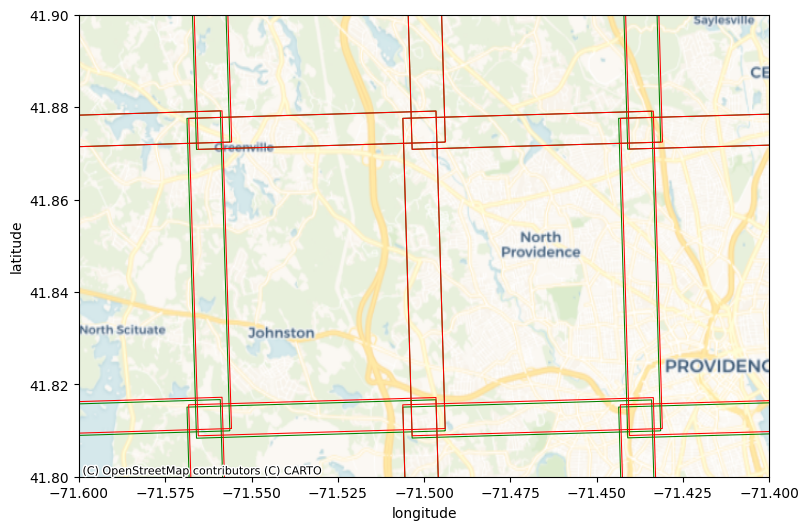

In [14]:
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6))
df_aoi.plot(ax=ax, ec='steelblue', fc='none', lw=0.5)
df_items_old.plot(ax=ax, ec='g', fc='none', lw=0.75)
df_items_new.plot(ax=ax, ec='r', fc='none', lw=0.75)
ax.set_xlim((-71.6, -71.4))
ax.set_ylim((41.8, 41.9))
cx.add_basemap(ax, crs='epsg:4326', source=cx.providers.CartoDB.Voyager)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

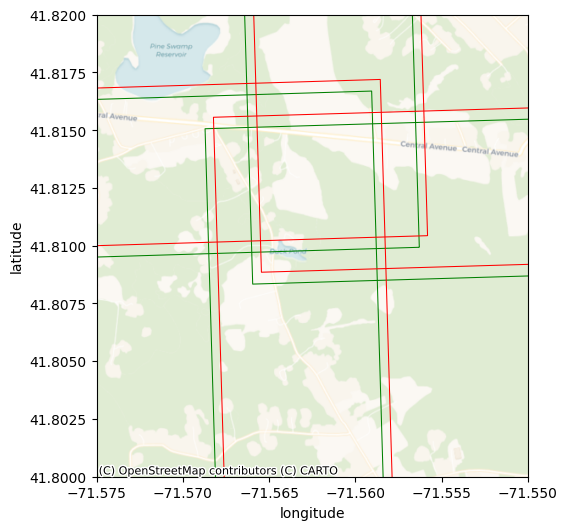

In [16]:
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6))
df_aoi.plot(ax=ax, ec='steelblue', fc='none', lw=0.5)
df_items_old.plot(ax=ax, ec='g', fc='none', lw=0.75)
df_items_new.plot(ax=ax, ec='r', fc='none', lw=0.75)
ax.set_xlim((-71.575, -71.550))
ax.set_ylim((41.8, 41.82))
cx.add_basemap(ax, crs='epsg:4326', source=cx.providers.CartoDB.Voyager)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

In [134]:
df_items_new[df_items_new['grid:code'] == 'DOQQ-4207159SW'].uri.tolist()

['s3://naip-analytic/ma/2021/60cm/rgbir_cog/42071/m_4207159_sw_19_060_20210926.tif',
 's3://naip-analytic/ma/2021/60cm/rgbir_cog/42071/m_4207159_sw_19_060_20210926.tif']

In [129]:
df_items_new.groupby(['grid:code']).size().reset_index().sort_values(0, ascending=False)

,grid:code,0
364,DOQQ-4207159SW,2
360,DOQQ-4207158SW,2
359,DOQQ-4207158SE,2
547,DOQQ-4207257SE,2
356,DOQQ-4207157SW,2
...,...,...
222,DOQQ-4207124NW,1
223,DOQQ-4207124SE,1
224,DOQQ-4207124SW,1
225,DOQQ-4207125NE,1


In [59]:
from IPython.display import display, HTML

def wrap_df_text(df):
    return display(HTML(df.to_html().replace("\\n","<br>")))

In [118]:
tmp = pd.merge(df_items_old, df_items_new, on='grid:code', how='inner')[['uri_x', 'uri_y']]
tmp['uri_x'] = tmp['uri_x'].str.wrap(42)
tmp['uri_y'] = tmp['uri_y'].str.wrap(42)

In [120]:
len(tmp)

685

In [119]:
wrap_df_text(tmp[['uri_x', 'uri_y']])

,uri_x,uri_y
0,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207258_nw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207258_nw_18_060_20211106.tif
1,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207250_sw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207250_sw_18_060_20211106.tif
2,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207250_nw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207250_nw_18_060_20211106.tif
3,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207242_sw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207242_sw_18_060_20211106.tif
4,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207234_sw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207234_sw_18_060_20211106.tif
5,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207227_sw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207227_sw_18_060_20211106.tif
6,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207227_nw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207227_nw_18_060_20211106.tif
7,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207226_sw_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207226_sw_18_060_20211106.tif
8,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207226_se_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207226_se_18_060_20211106.tif
9,s3://naip-analytic/ma/2018/60cm/rgbir_cog/42072/m_4207226_ne_18_060_20181123.tif,s3://naip-analytic/ma/2021/60cm/rgbir_cog/42072/m_4207226_ne_18_060_20211106.tif


In [70]:
!aws s3 cp s3://naip-analytic/vt/2018/60cm/rgbir_cog/42072/m_4207220_ne_18_060_20181123.tif data/ --request-payer=requester
!aws s3 cp s3://naip-analytic/vt/2021/60cm/rgbir_cog/42072/m_4207220_ne_18_060_20211019.tif data/ --request-payer=requester

download: s3://naip-analytic/vt/2018/60cm/rgbir_cog/42072/m_4207220_ne_18_060_20181123.tif to data/m_4207220_ne_18_060_20181123.tif
download: s3://naip-analytic/vt/2021/60cm/rgbir_cog/42072/m_4207220_ne_18_060_20211019.tif to data/m_4207220_ne_18_060_20211019.tif


In [23]:
with rio.Env():
    with rio.open('s3://naip-analytic/vt/2018/60cm/rgbir_cog/42072/m_4207220_ne_18_060_20181123.tif') as ds:
        print(ds.bounds)
        print(ds.shape)
    with rio.open('s3://naip-analytic/vt/2021/60cm/rgbir_cog/42072/m_4207220_ne_18_060_20211019.tif') as ds:
        print(ds.bounds)
        print(ds.shape)

INFO:botocore.credentials:Found credentials in environment variables.


BoundingBox(left=699184.8, bottom=4728693.6, right=705106.2, top=4736384.4)
(12818, 9869)
BoundingBox(left=699226.2, bottom=4728750.6, right=705104.3999999999, top=4736383.8)
(12722, 9797)


In [80]:
!aws s3 ls --request-payer=requester s3://naip-visualization/vt/2021/60cm/rgb/42072/m_4207220_ne_18_060_new1019.tif data/m_4207220_ne_18_060_new1019.tif

2023-03-01 18:09:31   58355284 m_4207220_ne_18_060_20211019.tif


In [ ]:
pd.merge(df_items_old, df_items_new, on='proj:bbox', how='inner')

In [81]:
from rastervision.core.data import XarraySource

In [ ]:
rs_old = XarraySource.from_stac(items_old[:10], allow_streaming=True, stackstac_args=dict(rescale=False, assets=['image']))

In [ ]:
crses_old = []
with tqdm(df_items_old.uri) as bar:
    for uri in bar:
        with rio.open(uri) as ds:
            crses_old.append(ds.crs)

In [93]:
set(crses_old)

{CRS.from_epsg(26918), CRS.from_epsg(26919)}

In [97]:
set(crses_old[:100])

{CRS.from_epsg(26918), CRS.from_epsg(26919)}

In [188]:
tmp = pd.merge(df_items_old, df_items_new, on='grid:code', how='inner')
len(tmp)

104

In [189]:
tmp.loc[:, 'intersection'] = tmp.geometry_x.intersection(tmp.geometry_y).area
tmp.loc[:, 'iou'] = tmp['intersection'] / tmp.geometry_x.union(tmp.geometry_y).area
tmp.loc[:, 'ioa_x'] = tmp['intersection'] / tmp.geometry_x.area
tmp.loc[:, 'ioa_y'] = tmp['intersection'] / tmp.geometry_y.area

In [190]:
tmp[['id_x', 'id_y', 'grid:code', 'iou', 'ioa_x', 'ioa_y']].sort_values('ioa_x')

,id_x,id_y,grid:code,iou,ioa_x,ioa_y
20,ri_m_4107118_ne_19_060_20180930_20181211,ri_m_4107118_ne_19_060_20210926,DOQQ-4107118NE,0.985216,0.985217,0.999999
91,ri_m_4107127_ne_19_060_20180816_20181211,ri_m_4107127_ne_19_060_20210926,DOQQ-4107127NE,0.985216,0.985220,0.999995
50,ri_m_4107131_ne_19_060_20180827_20181211,ri_m_4107131_ne_19_060_20210826,DOQQ-4107131NE,0.985232,0.985233,0.999999
32,ri_m_4107105_ne_19_060_20180930_20181211,ri_m_4107105_ne_19_060_20210826,DOQQ-4107105NE,0.985234,0.985235,0.999999
95,ri_m_4107120_ne_19_060_20180816_20181211,ri_m_4107120_ne_19_060_20210826,DOQQ-4107120NE,0.985238,0.985238,1.000000
...,...,...,...,...,...,...
21,ri_m_4107113_sw_19_060_20180930_20181211,ri_m_4107113_sw_19_060_20210826,DOQQ-4107113SW,0.985513,0.999903,0.985607
0,ri_m_4207161_sw_19_060_20180930_20181211,ri_m_4207161_sw_19_060_20210826,DOQQ-4207161SW,0.985577,0.999904,0.985670
47,ri_m_4107131_sw_19_060_20180827_20181211,ri_m_4107131_sw_19_060_20210826,DOQQ-4107131SW,0.985575,0.999905,0.985667
75,ri_m_4207159_sw_19_060_20180816_20181211,ri_m_4207159_sw_19_060_20211019,DOQQ-4207159SW,0.985607,0.999905,0.985699


In [10]:
# !gdalwarp \
# -t_srs "EPSG:26918" \
# -of VRT "/vsis3/raster-vision-ahassan/naip/2018_MA/m_4207220_ne_18_060_20181123.tif" \
# "data/m_4207220_ne_18_060_20181123_crs26918.vrt"

In [11]:
# !gdalbuildvrt test.vrt "/vsis3/naip-analytic/ri/2018/60cm/rgbir_cog/42071/m_4207161_sw_19_060_20180930.tif"

In [24]:
# !mkdir data/tmp_old
!mkdir data/tmp_new

In [11]:
# rs_old = RasterioSource(df_items_old.uri.tolist(), allow_streaming=True, tmp_dir='data/tmp_old/')
rs_old = RasterioSource('data/tmp_old/index.vrt')
rs_old.shape

INFO:botocore.credentials:Found credentials in environment variables.


(141383, 115465, 3)

In [12]:
# rs_new = RasterioSource(df_items_new.uri.tolist(), allow_streaming=True, tmp_dir='data/tmp_new/')
rs_new = RasterioSource('data/tmp_new/index.vrt')
rs_new.shape

INFO:botocore.credentials:Found credentials in environment variables.


(141381, 115533, 4)

In [5]:
bbox_old_map = rs_old.crs_transformer.pixel_to_map(rs_old.bbox)
bbox_new_map = rs_new.crs_transformer.pixel_to_map(rs_new.bbox)
bbox_intersection_map = Box.from_shapely(bbox_old_map.to_shapely().intersection(bbox_new_map.to_shapely()))
bbox_intersection_pixel_old = rs_old.crs_transformer.map_to_pixel(bbox_intersection_map).normalize()
bbox_intersection_pixel_new = rs_new.crs_transformer.map_to_pixel(bbox_intersection_map).normalize()

In [61]:
mapping(bbox_old_map.to_shapely().intersection(bbox_new_map.to_shapely()))['coordinates'][0]

((-71.0511579682806, 42.062711453388026),
 (-71.0511579682806, 41.31782760601769),
 (-71.91224110422583, 41.31782760601769),
 (-71.91224110422583, 42.062711453388026),
 (-71.0511579682806, 42.062711453388026))

In [6]:
bbox_old_map, bbox_new_map

(Box(ymin=42.062711453388026, xmin=-71.91224810581886, ymax=41.31732690460382, xmax=-71.0511579682806),
 Box(ymin=42.06319251749325, xmin=-71.91224110422583, ymax=41.31782760601769, xmax=-71.05065756330595))

In [7]:
bbox_intersection_map

Box(ymin=42.062711453388026, xmin=-71.91224110422583, ymax=41.31782760601769, xmax=-71.0511579682806)

In [8]:
bbox_intersection_pixel_old, bbox_intersection_pixel_new

(Box(ymin=0, xmin=1, ymax=141290, xmax=115467),
 Box(ymin=89, xmin=-3, ymax=141379, xmax=115463))

In [10]:
rs_old.set_bbox(bbox_intersection_pixel_old)
rs_new.set_bbox(bbox_intersection_pixel_new)

In [34]:
rs_old.crs_transformer.pixel_to_map(Box(50_000, 50_000, 50_400, 50_400))

Box(ymin=41.80140150902098, xmin=-71.53930074410266, ymax=41.79930575648225, xmax=-71.53632939984371)

In [21]:
chip_old = rs_old[52_000:52_400, 51_000:51_400]
chip_new = rs_new[52_000:52_400, 51_000:51_400]

INFO:botocore.credentials:Found credentials in environment variables.
INFO:botocore.credentials:Found credentials in environment variables.


In [46]:
rs_new.crs_transformer.map_to_pixel(w, rs_new.bbox).to_global_coords(rs_new.bbox)

Box(ymin=50089, xmin=49996, ymax=50489, xmax=50396)

In [14]:
w = Box(ymin=41.80140150902098, xmin=-71.53930074410266, ymax=41.79930575648225, xmax=-71.53632939984371)
chip_old = rs_old.get_chip_by_map_window(w)
chip_new = rs_new.get_chip_by_map_window(w)

INFO:botocore.credentials:Found credentials in environment variables.
INFO:botocore.credentials:Found credentials in environment variables.


In [12]:
rs_old.crs_transformer.map_to_pixel(w).normalize(), rs_new.crs_transformer.map_to_pixel(w).normalize()

(Box(ymin=50000, xmin=50000, ymax=50400, xmax=50400),
 Box(ymin=50089, xmin=49996, ymax=50489, xmax=50396))

In [28]:
mu_old = chip_old.reshape(-1, 3).mean(axis=0)
sigma_old = chip_old.reshape(-1, 3).std(axis=0)
mu_new = chip_new[..., :3].reshape(-1, 3).mean(axis=0)
sigma_new = chip_new[..., :3].reshape(-1, 3).std(axis=0)

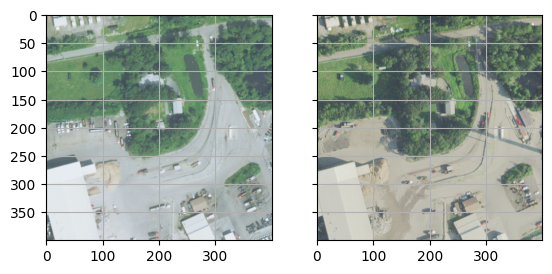

In [15]:
fig, (ax_old, ax_new) = plt.subplots(1, 2, sharex=True, sharey=True)
ax_old.imshow(chip_old[..., :3])
ax_new.imshow(chip_new[..., :3])
# ax_old.axis('off')
# ax_new.axis('off')
ax_old.grid()
ax_new.grid()
plt.show()

---

In [23]:
with open('uris_old.txt', 'w') as f:
    f.write('\n'.join([uri_to_vsi_path(uri) for uri in df_items_old.uri]))

In [22]:
with open('uris_new.txt', 'w') as f:
    f.write('\n'.join([uri_to_vsi_path(uri) for uri in df_items_new.uri]))

In [12]:
!gdalbuildvrt -input_file_list "uris_old.txt" "mosaic_old.vrt"

0...10...20...30...40...50...60...70...80...90...100 - done.


In [13]:
!gdalbuildvrt -input_file_list "uris_new.txt" "mosaic_new.vrt"

0^C


In [31]:
!rm "mosaic_reproj_old.vrt"
!gdalwarp \
-t_srs "EPSG:5070" \
-of VRT "mosaic_old.vrt" \
"mosaic_reproj_old.vrt"

rm: cannot remove 'mosaic_reproj_old.vrt': No such file or directory
Using band 4 of source image as alpha.
Creating output file that is 149982P x 168919L.
Processing mosaic_old.vrt [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


In [32]:
!rm "mosaic_reproj_new.vrt"
!gdalwarp \
-t_srs "EPSG:5070" \
-of VRT "mosaic_new.vrt" \
"mosaic_reproj_new.vrt"

Creating output file that is 150047P x 168937L.
Processing mosaic_new.vrt [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


In [33]:
rs_old = RasterioSource('mosaic_reproj_old.vrt', channel_order=[0, 1, 2])
rs_old.shape

INFO:botocore.credentials:Found credentials in environment variables.


(168919, 149982, 3)

In [34]:
rs_new = RasterioSource('mosaic_reproj_new.vrt', channel_order=[0, 1, 2])
rs_new.shape

INFO:botocore.credentials:Found credentials in environment variables.


(168937, 150047, 3)

In [18]:
w = Box(ymin=41.80140150902098, xmin=-71.53930074410266, ymax=41.79930575648225, xmax=-71.53632939984371)
chip_old = rs_old.get_chip_by_map_window(w)
chip_new = rs_new.get_chip_by_map_window(w)

INFO:botocore.credentials:Found credentials in environment variables.
INFO:botocore.credentials:Found credentials in environment variables.


In [19]:
chip_old.shape, chip_new.shape

((274, 494, 3), (273, 494, 3))

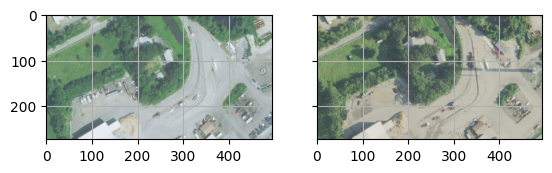

In [20]:
fig, (ax_old, ax_new) = plt.subplots(1, 2, sharex=True, sharey=True)
ax_old.imshow(chip_old[..., :3])
ax_new.imshow(chip_new[..., :3])
# ax_old.axis('off')
# ax_new.axis('off')
ax_old.grid()
ax_new.grid()
plt.show()

In [40]:
ws = rs_new.extent.get_windows(400, 400, padding=0)
len(ws)

107985

In [ ]:
!gdalinfo {uri_to_vsi_path(df_items_new.uri.iloc[0])}

In [62]:
def loc_to_gmaps_url(loc):
    return f'https://www.google.com/maps/@{loc.y},{loc.x},220m/data=!3m1!1e3'

In [63]:
loc_to_gmaps_url(w.to_shapely().centroid)

'https://www.google.com/maps/@41.80035363275161,-71.5378150719732,220m/data=!3m1!1e3'

In [35]:
rs_new._crs_transformer = RasterioCRSTransformer.from_uri('mosaic_reproj_new.vrt', map_crs='epsg:5070')
# rs_new._crs_transformer = RasterioCRSTransformer.from_uri('mosaic_reproj_new.vrt', map_crs='ESRI:102003')

INFO:botocore.credentials:Found credentials in environment variables.


In [24]:
rs_new.crs_transformer.pixel_to_map(Box(50_000, 50_000, 50_400, 50_400)).size

(-240.23809240816627, 240.23809240828268)

In [98]:
w_map = rs_new.crs_transformer.pixel_to_map(Box(0, 0, 399, 399))

In [119]:
ws = rs_new.bbox.get_windows(500, 500, padding=0)
len(ws)

101100

In [142]:
i = np.random.randint(len(ws))
rs_new.crs_transformer.pixel_to_map(ws[i]).size

(-300.29761551041156, 300.29761551041156)

INFO:botocore.credentials:Found credentials in environment variables.


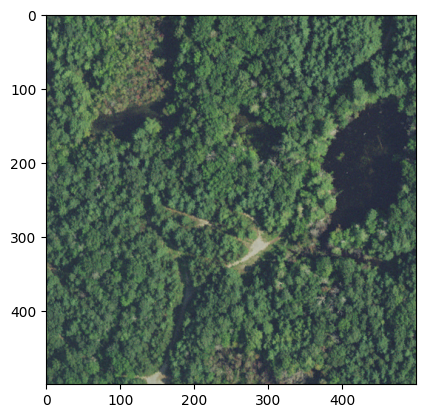

In [143]:
plt.imshow(rs_new[ws[i]])
plt.show()

In [107]:
rs_new.crs_transformer.pixel_to_map(ws[i])

Box(ymin=2326043.049272958, xmin=1981028.8724380045, ymax=2325802.81118055, xmax=1981269.1105304128)

In [114]:
rs_new.crs_transformer.map_to_pixel(
    Box(ymin=2326043.049272958, xmin=1981028.8724380045, ymax=(2326043.049272958+240), xmax=(1981028.8724380045+240))
).normalize().size

(400, 400)

In [16]:
rs_new._crs_transformer = RasterioCRSTransformer.from_uri('mosaic_reproj_new.vrt', map_crs='EPSG:5070')

INFO:botocore.credentials:Found credentials in environment variables.


In [45]:
aoi_map = df_aoi.to_crs('EPSG:5070').geometry.unary_union
bbox = Box.from_shapely(aoi_map)
bbox

Box(ymin=2288312.019486154, xmin=1969277.2898143088, ymax=2373593.9973981944, xmax=2038041.4440678733)

In [101]:
windows_map = SlidingWindows(bbox, size=300, stride=300, padding=0)
len(windows_map)

65036

In [50]:
df = df_items_new.to_crs('EPSG:5070')

In [102]:
items_coverage_geom = df.unary_union
window_filter_geom = aoi_map.intersection(items_coverage_geom)
windows_map = Box.filter_by_aoi(windows_map, [window_filter_geom], within=True)
len(windows_map)

29040

In [103]:
windows_df = gpd.GeoDataFrame(
    geometry=[w.to_shapely() for w in windows_map], crs='epsg:5070'
)
windows_df

,geometry
0,"POLYGON ((1983977.29 2288612.019, 1983977.29 2..."
1,"POLYGON ((1983977.29 2288912.019, 1983977.29 2..."
2,"POLYGON ((1984277.29 2288912.019, 1984277.29 2..."
3,"POLYGON ((1984577.29 2288912.019, 1984577.29 2..."
4,"POLYGON ((1983977.29 2289212.019, 1983977.29 2..."
...,...
29035,"POLYGON ((2001977.29 2372612.019, 2001977.29 2..."
29036,"POLYGON ((2000777.29 2372912.019, 2000777.29 2..."
29037,"POLYGON ((2001077.29 2372912.019, 2001077.29 2..."
29038,"POLYGON ((2001377.29 2372912.019, 2001377.29 2..."


In [115]:
join_df: gpd.GeoDataFrame = windows_df.sjoin(df[["uri", "geometry"]], how="left")
join_df

,geometry,index_right,uri
0,"POLYGON ((1983977.29 2288612.019, 1983977.29 2...",10,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4107...
1,"POLYGON ((1983977.29 2288912.019, 1983977.29 2...",10,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4107...
2,"POLYGON ((1984277.29 2288912.019, 1984277.29 2...",10,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4107...
3,"POLYGON ((1984577.29 2288912.019, 1984577.29 2...",10,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4107...
4,"POLYGON ((1983977.29 2289212.019, 1983977.29 2...",10,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4107...
...,...,...,...
29035,"POLYGON ((2001977.29 2372612.019, 2001977.29 2...",57,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4207...
29036,"POLYGON ((2000777.29 2372912.019, 2000777.29 2...",57,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4207...
29037,"POLYGON ((2001077.29 2372912.019, 2001077.29 2...",57,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4207...
29038,"POLYGON ((2001377.29 2372912.019, 2001377.29 2...",57,s3://naip-analytic/ri/2021/60cm/rgbir_cog/4207...


In [124]:
join_df.uri.isna().any()

False

In [105]:
unmatched_windows_df = join_df[join_df.uri.isna()]
unmatched_windows_df

,geometry,index_right,uri


In [130]:
join_df.groupby('geometry').size().reset_index().groupby(0).size()

0
1    18859
2     8874
3      540
4      767
dtype: int64

In [117]:
join_df2 = join_df.groupby(['geometry'])['uri'].apply(';'.join).reset_index()

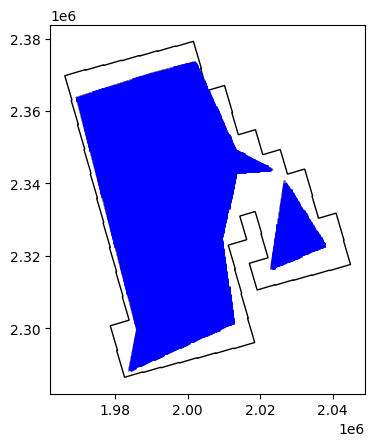

In [123]:
fig, ax = plt.subplots()
items_patch = patches.Polygon(np.array(items_coverage_geom.exterior.xy).T, fc='none', ec='k')
ax.add_patch(items_patch)
for p in aoi_map.geoms:
    poly_patch = patches.Polygon(np.array(p.exterior.xy).T, fc='none', ec='r')
    ax.add_patch(poly_patch)
for p in window_filter_geom.geoms:
    poly_patch = patches.Polygon(np.array(p.exterior.xy).T, fc='none', ec='steelblue')
    ax.add_patch(poly_patch)
# unmatched_windows_df.plot(ax=ax, fc='none', ec='b', lw=2)
join_df.plot(ax=ax, fc='none', ec='b', lw=2)
# ax.set_xlim((2*1e6, 2.012*1e6))
# ax.set_ylim((2.36*1e6, 2.37*1e6))
plt.show()

In [135]:
gpd.GeoDataFrame(pd.DataFrame.from_records([{'a': 1}]), geometry=[p])

,a,geometry
0,1,"POLYGON ((2004741.058 2367776.01, 2005371.882 ..."


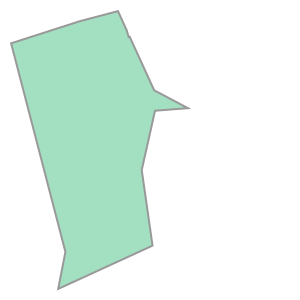

In [131]:
p

INFO:botocore.credentials:Found credentials in environment variables.


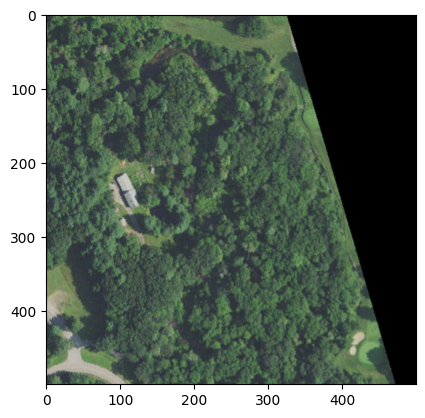

In [100]:
plt.imshow(rs_new.get_chip_by_map_window(windows_map[29014]))
plt.show()

In [ ]:
i = np.random.randint(len(ws))
plt.imshow(rs_new[ws[i]])
plt.show()

In [21]:
bbox = Box.from_shapely(df_aoi.to_crs(5070).geometry.unary_union)
ws = SlidingWindows(bbox, size=300, stride=300, padding=0)
with tqdm(ws) as bar:
    df_ws = gpd.GeoDataFrame(geometry=[w.to_shapely() for w in bar], crs=5070)

  0%|          | 0/65036 [00:00<?, ?it/s]

In [31]:
df_ws.loc[:, 'geometry_w'] = df_ws.geometry
tmp = df_items_new.to_crs(5070).sjoin(df_ws, how='inner')
len(tmp)

57063

In [45]:
w_geom = tmp.groupby('geometry_w').size().reset_index().sort_values(0, ascending=False).geometry_w.iloc[0]

In [46]:
w = Box.from_shapely(w_geom)

In [48]:
w

Box(ymin=2316512.019486154, xmin=1985777.2898143088, ymax=2316812.019486154, xmax=1986077.2898143088)

In [50]:
rs_new._crs_transformer = RasterioCRSTransformer.from_uri('mosaic_reproj_new.vrt', map_crs='epsg:5070')

INFO:botocore.credentials:Found credentials in environment variables.


In [51]:
chip = rs_new.get_chip_by_map_window(w)
chip.shape

INFO:botocore.credentials:Found credentials in environment variables.


(499, 500, 3)

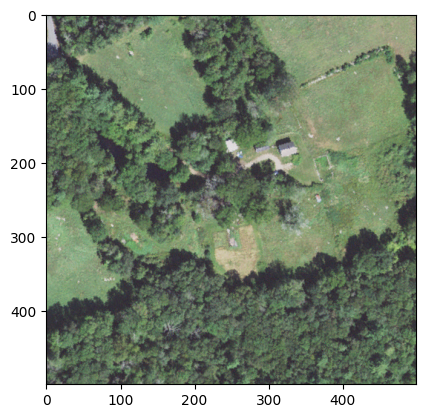

In [52]:
plt.imshow(chip)
plt.show()

In [64]:
df_aoi = df_aoi.to_crs(5070)

In [72]:
scene = Scene('', rs_new, aoi_polygons=[rs_new.crs_transformer.map_to_pixel(g) for g in df_aoi.geometry])

In [74]:
ds = SemanticSegmentationSlidingWindowGeoDataset(scene, 500, 500, transform=A.Resize(224, 224))
len(ds)

28988

In [75]:
bbox = Box.from_shapely(df_aoi.to_crs(5070).geometry.unary_union)
ds.windows = SlidingWindows(bbox, size=300, stride=300, padding=0)
ds.windows = Box.filter_by_aoi(
    ds.windows,
    ds.scene.aoi_polygons_bbox_coords,
    within=True)

In [76]:
len(ds)

28988

In [74]:
(df_aoi.to_crs(5070).geometry.unary_union.area / 1e6) / (.3**2)

29654.89276648001

In [22]:
chip_size_km = 30
f'US {round(8e6 / (chip_size_km**2)):,}, {round(8e6 / (chip_size_km**2) * 768 * 4 / 2**30, 1):,} GB', \
f'AL {round(1.73e6 / (chip_size_km**2)):,}, {round(1.73e6 / (chip_size_km**2) * 768 * 4 / 2**30, 1):,} GB', \
f'TX {round(700_000 / (chip_size_km**2)):,}, {round(700_000 / (chip_size_km**2) * 768 * 4 / 2**30, 1):,} GB', \
f'FL {round(170_300 / (chip_size_km**2)):,}, {round(170_300 / (chip_size_km**2) * 768 * 4 / 2**30, 1):,} GB', \
f'MA {round(27_300 / (chip_size_km**2)):,} {round(27_300 / (chip_size_km**2) * 768 * 4 / 2**30, 1):,} GB', \
f'RI {round(4_000 / (chip_size_km**2)):,} {round(4_000 / (chip_size_km**2) * 768 * 4 / 2**30, 1):,} GB'

('US 8,889, 0.0 GB',
 'AL 1,922, 0.0 GB',
 'TX 778, 0.0 GB',
 'FL 189, 0.0 GB',
 'MA 30 0.0 GB',
 'RI 4 0.0 GB')

In [77]:
chip, _ = ds[0]

INFO:botocore.credentials:Found credentials in environment variables.


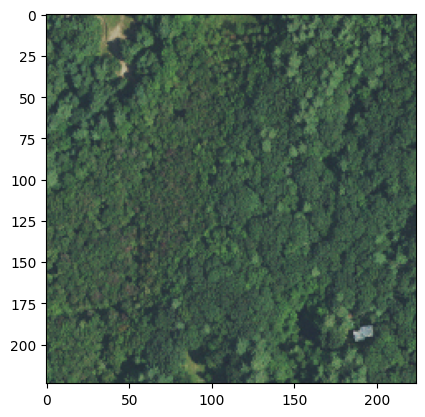

In [79]:
plt.imshow(chip.permute(1, 2, 0))
plt.show()

In [8]:
bbox = Box.from_shapely(df_aoi.to_crs('ESRI:102003').geometry.unary_union)
ws = SlidingWindows(bbox, size=300, stride=300, padding=0)

In [9]:
ws[0]

Box(ymin=681525.7589088179, xmin=1969277.2898143088, ymax=681825.7589088179, xmax=1969577.2898143088)

In [17]:
rs_new.crs_transformer.map_to_pixel(ws[50_000]).size

(499.5044657450635, 499.50446574483067)

In [12]:
rs_new.crs_transformer.pixel_to_map(rs_new.crs_transformer.map_to_pixel(ws[0]))

Box(ymin=681525.7589088179, xmin=1969277.2898143088, ymax=681825.758908818, xmax=1969577.2898143085)

INFO:botocore.credentials:Found credentials in environment variables.


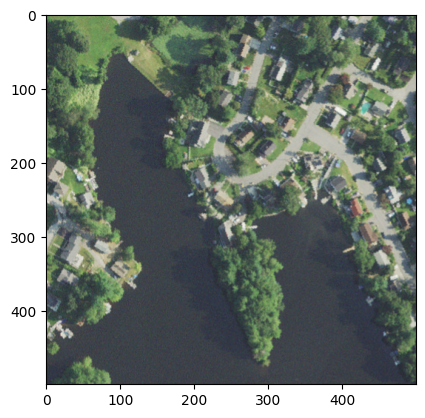

In [16]:
# chip = rs_new.get_chip_by_map_window(ws[50_000])
chip = rs_new.get_chip(rs_new.crs_transformer.map_to_pixel(ws[50_000]))
plt.imshow(chip)
plt.show()

In [57]:
from rasterio.windows import from_bounds, bounds

In [61]:
ws[50_000]

Box(ymin=746925.7589088179, xmin=1992677.2898143088, ymax=747225.7589088179, xmax=1992977.2898143088)

In [48]:
rio_w = from_bounds(*ws[50_000].to_xyxy(), transform=rs_new.image_dataset.transform)

In [53]:
(ymin, ymax), (xmin, xmax) = rio_w.toranges()
Box(ymin, xmin, ymax, xmax)

Box(ymin=55031.7482540512, xmin=56595.2883277582, ymax=55531.25271979626, xmax=57094.79279350303)

In [64]:
bounds(Window(*Box.from_rasterio(rio_w).to_xywh()), transform=rs_new.image_dataset.transform)

(1992677.116646032, 746925.3100958914, 1992977.4142615425, 747226.2083066327)

In [49]:
rio_w, Box.from_rasterio(rio_w)

(Window(col_off=56595.2883277582, row_off=55031.7482540512, width=499.50446574483067, height=499.5044657450635),
 Box(ymin=55031, xmin=56595, ymax=55532, xmax=57095))

INFO:botocore.credentials:Found credentials in environment variables.


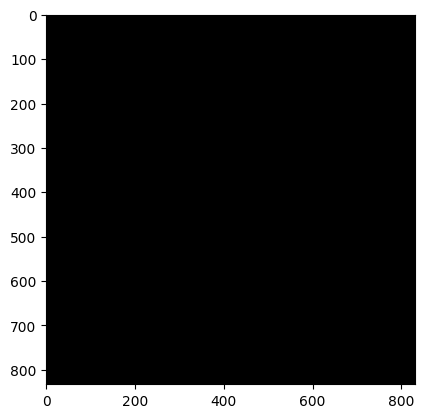

In [41]:
chip = rs_new.get_chip_by_map_window(rs_new.crs_transformer.map_to_pixel(ws[50_000]))
plt.imshow(chip)
plt.show()